# Perceptron From Scratch: Manufacturing Quality Control

In this notebook, we build a perceptron using only standard Python. The model learns to classify inspected parts as **ACCEPT** or **REJECT**.

By the end, you will be able to explain the weighted sum, step activation function, error, and perceptron update rule.

## 1. The classification task

An inspection process supplies two numeric measurements directly to the model:

| Feature | Meaning |
|---|---|
| `dimension_error_mm` | Absolute deviation from the target dimension, in millimetres |
| `surface_defects` | Number of visible surface defects |

Labels are **ACCEPT = 1** and **REJECT = 0**. Larger measurement values should generally push a part toward rejection.

> This is realistic synthetic teaching data, not measurements from a production process.

In [6]:
import random

random.seed(42)
weights = [random.uniform(-1, 1), random.uniform(-1, 1)]
bias = random.uniform(-1, 1)
learning_rate = 0.1
max_epochs = 100

print("Starting weights:", [round(weight, 3) for weight in weights])
print(f"Starting bias: {bias:.3f}")

Starting weights: [0.279, -0.95]
Starting bias: -0.450


## 2. Training and test observations

The training set contains 12 inspected parts. Four separate parts are held back so we can test the learned model on unseen measurements.

In [7]:
training_data = [
    ("P01", [0.10, 0], 1), ("P02", [0.15, 1], 1),
    ("P03", [0.20, 0], 1), ("P04", [0.25, 1], 1),
    ("P05", [0.30, 0], 1), ("P06", [0.05, 1], 1),
    ("P07", [0.55, 0], 0), ("P08", [0.45, 2], 0),
    ("P09", [0.20, 3], 0), ("P10", [0.70, 1], 0),
    ("P11", [0.35, 2], 0), ("P12", [0.60, 2], 0),
]

test_cases = [
    ("T01", [0.12, 0], 1),
    ("T02", [0.28, 1], 1),
    ("T03", [0.50, 1], 0),
    ("T04", [0.10, 3], 0),
]

print(f"Training observations: {len(training_data)}")
print(f"Unseen test observations: {len(test_cases)}")

Training observations: 12
Unseen test observations: 4


## 3. Weighted sum and step activation function

For features $x_1$ and $x_2$, the perceptron computes:

$$score = w_1x_1 + w_2x_2 + b$$

The step activation function converts the numerical score into a binary class: it predicts `1` when the score is at least zero and `0` otherwise.

In [9]:
def predict(features, weights, bias):
    """Return 1 for ACCEPT or 0 for REJECT."""
    total = weights[0] * features[0] + weights[1] * features[1] + bias
    # Step activation function: scores >= 0 map to 1; scores < 0 map to 0.
    return 1 if total >= 0 else 0

sample_id, sample_features, sample_target = training_data[0]
print(f"Initial prediction for {sample_id}: {predict(sample_features, weights, bias)}")
print(f"Correct label for {sample_id}: {sample_target}")

Initial prediction for P01: 0
Correct label for P01: 1


## 4. Learning from errors

For each part, calculate `error = target - prediction`. When the prediction is wrong, update each weight using:

`weight = weight + learning_rate × error × feature`

The bias receives the same update without a feature value. One pass through all observations is an **epoch**.

In [10]:
history = []
for epoch in range(max_epochs):
    errors = 0
    for part_id, features, target in training_data:
        prediction = predict(features, weights, bias)
        error = target - prediction
        if error != 0:
            errors += 1
            weights[0] += learning_rate * error * features[0]
            weights[1] += learning_rate * error * features[1]
            bias += learning_rate * error

    history.append(errors)
    print(f"Epoch {epoch + 1:3d} | Errors: {errors}")
    if errors == 0:
        print(f"Training complete after {epoch + 1} epoch(s).")
        break
else:
    raise RuntimeError("The perceptron did not converge within 100 epochs.")

Epoch   1 | Errors: 6
Epoch   2 | Errors: 6
Epoch   3 | Errors: 4
Epoch   4 | Errors: 2
Epoch   5 | Errors: 3
Epoch   6 | Errors: 2
Epoch   7 | Errors: 2
Epoch   8 | Errors: 3
Epoch   9 | Errors: 3
Epoch  10 | Errors: 3
Epoch  11 | Errors: 3
Epoch  12 | Errors: 2
Epoch  13 | Errors: 1
Epoch  14 | Errors: 0
Training complete after 14 epoch(s).


## 5. Error history

A simple text chart shows how the number of mistakes changes while the boundary moves.

In [11]:
for epoch, errors in enumerate(history, start=1):
    print(f"Epoch {epoch:3d}: {'#' * errors} ({errors})")

Epoch   1: ###### (6)
Epoch   2: ###### (6)
Epoch   3: #### (4)
Epoch   4: ## (2)
Epoch   5: ### (3)
Epoch   6: ## (2)
Epoch   7: ## (2)
Epoch   8: ### (3)
Epoch   9: ### (3)
Epoch  10: ### (3)
Epoch  11: ### (3)
Epoch  12: ## (2)
Epoch  13: # (1)
Epoch  14:  (0)


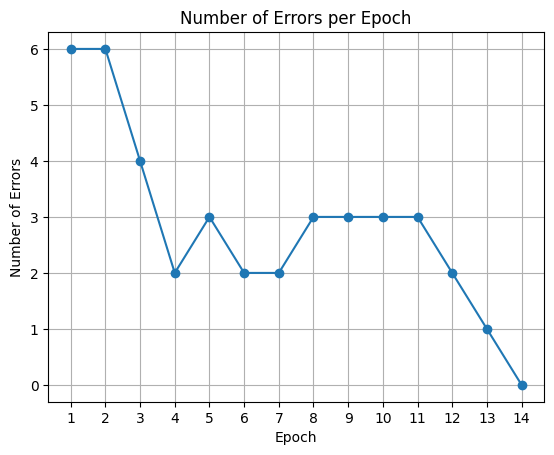

In [12]:
# plot a line graph of the number of errors per epoch
import matplotlib.pyplot as plt
def plot_errors(errors):
    plt.plot(range(1, len(errors) + 1), errors, marker='o')
    plt.title('Number of Errors per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Number of Errors')
    plt.xticks(range(1, len(errors) + 1))
    plt.grid()
    plt.show()

plot_errors(history)


## 6. Test unseen parts

These four observations were not used to update the weights.

In [13]:
for part_id, features, expected in test_cases:
    prediction = predict(features, weights, bias)
    label = "ACCEPT" if prediction == 1 else "REJECT"
    expected_label = "ACCEPT" if expected == 1 else "REJECT"
    print(
        f"{part_id}: dimension error={features[0]:.2f} mm, "
        f"surface defects={features[1]} -> {label} (expected {expected_label})"
    )
    assert prediction == expected

T01: dimension error=0.12 mm, surface defects=0 -> ACCEPT (expected ACCEPT)
T02: dimension error=0.28 mm, surface defects=1 -> ACCEPT (expected ACCEPT)
T03: dimension error=0.50 mm, surface defects=1 -> REJECT (expected REJECT)
T04: dimension error=0.10 mm, surface defects=3 -> REJECT (expected REJECT)


## 7. Interpret the learned parameters

A negative weight means that increasing that measurement lowers the score and pushes the prediction toward `REJECT`. The bias moves the decision threshold.

In [14]:
feature_names = ["Dimension error", "Surface defects"]
for feature_name, weight in zip(feature_names, weights):
    print(f"{feature_name:16s}: {weight:+.3f}")
print(f"{'Bias':16s}: {bias:+.3f}")

assert weights[0] < 0 and weights[1] < 0
print("Both learned feature weights push larger measurements toward REJECT.")

Dimension error : -0.331
Surface defects : -0.050
Bias            : +0.150
Both learned feature weights push larger measurements toward REJECT.
